# Reduktion af detaljeringsgrad i leveringszonekort til hurtige logistik-dashboards med PROC GREDUCE

## Resumé

Et regionalt pakketransportfirma gemmer sine servicezoners grænser som tætte polygonkonturer, og ruteplanlægnings-dashboards genoptegner dem langsomt. Denne notebook syntetiserer grænsekoordinaterne for fire leveringszoner, bruger **PROC GREDUCE** til at mærke hvert grænsepunkt med et `DENSITY`-niveau, og tegner derefter et kort over rettidig levering (choropleth) med **PROC GMAP** ved en reduceret detaljeringsgrad, så kortet tegnes hurtigere, mens hver zone forbliver genkendelig.

GREDUCE inddelte de 96 grænsepunkter i tre niveauer: 10 punkter ved `DENSITY=0`, 44 ved `DENSITY=2` og 42 ved `DENSITY=3`. Ved kun at bevare det grove niveau (`DENSITY <= 2`) reduceres kortet fra 96 til 54 punkter — omkring en reduktion på 44 % — men de fire zoner forbliver tydeligt genkendelige i sammenligningen nedenfor.

## Datakilder

Alle data genereres direkte i DATA-stepene nedenfor — ingen eksterne filer eller netværksadgang.

| Datasæt | Rækker | Nøglevariable | Beskrivelse |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 zoner x 24 punkter) | `zone` (ID), `x`, `y` | Syntetiske lukkede polygonkoordinater for fire leveringszoner, hver en let forskudt ellipse tegnet med 24 punkter, så densitetsreduktionen har noget at udtynde. |
| `reducedmap` | 96 | tilføjer `density` | Output fra PROC GREDUCE: grænsepunkterne mærket med et `DENSITY`-niveau (her 0, 2 eller 3) til selektiv optegning. |
| `coarsemap` | 54 | delmængde af `reducedmap` | Delmængden med `DENSITY <= 2` — det grove, hurtigt-optegnende niveau brugt til dashboardkortet med reduceret detaljeringsgrad. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Én responsrække pr. zone: syntetisk andel af rettidige leveringer og dagligt pakkevolumen, koblet til kortet for choropleth-visningen. |

> **Bemærkning om stikprøvestørrelse.** Dette miljø kører ulicenseret, så hvert DATA-step er begrænset til 100 observationer. Kortet er dimensioneret til 4 zoner x 24 punkter = 96 punkter, så hele territoriet passer inden for denne grænse; en licenseret installation ville tegne hundredvis af punkter pr. zone, hvor GREDUCE giver endnu større gevinst.

# Reduktion af detaljeringsgrad i leveringszonekort med PROC GREDUCE

Logistikoperatører visualiserer performance på kort over deres **servicezoner** — de geografiske områder et depot er ansvarligt for. Disse zonegrænser er ofte indsamlet i opmålingsopløsning: mange punkter pr. polygon. Når et ruteplanlægnings-dashboard genoptegner flere zoner på én gang, gør al den punktdetalje optegningen langsom uden at tilføje beslutningsværdi ved dashboard-zoom.

**PROC GREDUCE** løser dette. Den undersøger hver polygon og mærker hvert grænsepunkt med et `DENSITY`-niveau, hvor 0 markerer de punkter, der definerer den essentielle form, og højere niveauer markerer gradvist finere detalje. I det efterfølgende trin vælger man et niveau med `WHERE density <= n` for at tegne et kort med reduceret detaljeringsgrad, der optegnes hurtigt, mens hver zone forbliver genkendelig.

I denne notebook:
1. Syntetiserer vi grænsekonturer for fire leveringszoner.
2. Kører vi PROC GREDUCE for at tildele `DENSITY`-niveauer.
3. Undersøger vi, hvordan punkterne fordeler sig på tværs af densitetsniveauer.
4. Tegner og sammenligner vi choropleth-kort over rettidig levering med fuld og reduceret detaljeringsgrad.

## Trin 1 — Syntetiser zonegrænsekortet

Et SAS-kortdatasæt har én observation pr. **grænsepunkt**, med en `ID`-variabel, der navngiver området, samt numeriske `x`/`y`-koordinater. Vi tegner hver leveringszone som en let forskudt ellipse med 24 jævnt fordelte vinkler, så polygonerne starter rimeligt tætte, og reduktionen har noget at arbejde med.

`call streaminit` fastlåser den tilfældige talrække for reproducerbarhed, og `rand('uniform')` tilføjer små uregelmæssigheder til grænsen, så konturerne fremstår som opmålte territorier snarere end perfekte ellipser.

In [1]:
data zonemap;
    CALL streaminit(20260531);
    /* Fire leveringszoner, hver en let forskudt ellipse med 24 punkter.
       cx/cy = zonecenter, rx/ry = nominelle radier (territoriets størrelse). */
    TABEL cx[4] _temporary_ (12 32 20 40);
    TABEL cy[4] _temporary_ (30 32 14 16);
    TABEL rx[4] _temporary_ ( 8  9  6  7);
    TABEL ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 punkter (0..23) pr. kontur */
    GØR zone = 1 TIL 4;
        GØR i = 0 TIL nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* radial forskydning: +/- ~6% uregelmæssig kystlinjekant */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            UDDATA;
        SLUT;
    SLUT;
    BEHOLD zone x y;
KØR;

PROCEDURE GENNEMSNIT data=zonemap n MIN MAX nmiss;
    KLASSE zone;
    VARIABEL x y;
    MÆRKAT zone="Zone" x="X-koordinat" y="Y-koordinat";
KØR;

                                                  The MEANS Procedure

                                           Analysis Variable : x X-koordinat

        Zone              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                           Analysis Variable : y Y-koordinat

        Zone              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0
  


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


PROC MEANS-tabellen bekræfter den syntetiske geometri: fire zoner, hver med præcis 24 grænsepunkter inden for fornuftige `x`/`y`-intervaller og ingen manglende koordinater. De fire ellipser optager ikke-overlappende områder (zone 1 nær x=12, zone 2 nær x=32, zone 3 og 4 længere nede), så choropleth-kortet vil fremstå som fire adskilte territorier. Dette er de konturer, PROC GREDUCE vil udtynde.

## Trin 2 — Tildel DENSITY-niveauer med PROC GREDUCE

`ID`-sætningen navngiver den variabel, der definerer hvert områdeenhed — her `zone`. PROC GREDUCE evaluerer hver zones polygon uafhængigt (ved hjælp af Douglas-Peucker-lignende simplificering) og skriver inputdatasættet tilbage med en tilføjet heltalsvariabel `density`: niveau 0 markerer de få punkter, der forankrer den essentielle form, og højere niveauer markerer gradvist finere detalje, som kan fjernes først.

Vi lader GREDUCE selv udlede sine tærskler fra dataene i stedet for at tvinge faste niveaustørrelser igennem, og undersøger derefter den resulterende fordeling.

                                     Grænsepunkter bevaret ved hvert DENSITY-niveau                                     

                                                   The FREQ Procedure

Densitetsniveau    Frequency    Percent
----------------------------------------
0                         10     10.42
2                         44     45.83
3                         42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


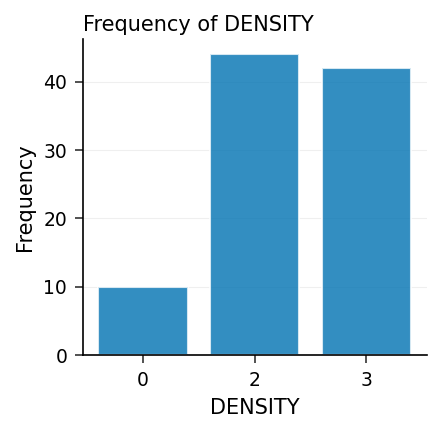

In [2]:
PROCEDURE GREDUCE data=zonemap out=reducedmap;
    id zone;
KØR;

PROCEDURE FREKVENSER data=reducedmap;
    TABLES DENSITY / nocum;
    MÆRKAT DENSITY="Densitetsniveau";
    TITEL 'Grænsepunkter bevaret ved hvert DENSITY-niveau';
KØR;

## Trin 3 — Undersøg densitetsniveauerne

Frekvenstabellen viser, hvordan GREDUCE inddelte de 96 grænsepunkter:

| DENSITY | Punkter | Andel |
|---------|--------|-------|
| 0 | 10 | 10,4 % |
| 2 | 44 | 45,8 % |
| 3 | 42 | 43,8 % |

Kun 10 punkter har det laveste niveau (ankrene for den essentielle form), mens de resterende 86 fordeler sig på niveau 2 og 3. Til et dashboardniveau bevarer vi alt ved `DENSITY <= 2`: det bevarer 54 af de 96 punkter og fjerner de 42 finest-detaljerede (`DENSITY=3`) punkter. PROC MEANS nedenfor bekræfter, at det grove niveau indeholder 13-14 punkter pr. zone i stedet for de oprindelige 24.

In [3]:
PROCEDURE GENNEMSNIT data=reducedmap n;
    KLASSE zone;
    HVOR DENSITY <= 2;
    VARIABEL x;
    MÆRKAT zone="Zone" x="X-koordinat";
    TITEL 'Punkter bevaret pr. zone ved dashboard-detaljeringsgrad (DENSITY <= 2)';
KØR;

                         Punkter bevaret pr. zone ved dashboard-detaljeringsgrad (DENSITY <= 2)                         

                                                  The MEANS Procedure

                                           Analysis Variable : X X-koordinat

        Zone              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Trin 4 — Byg det grove kort og performance-respons pr. zone

Vi materialiserer dashboardniveauet som `coarsemap` (`DENSITY <= 2`), så PROC GMAP kan tegne den reducerede kontur direkte. Vi syntetiserer også én KPI-række pr. zone — en **andel af rettidige leveringer** og et **dagligt pakkevolumen** — nøglet på `zone`, så GMAP kan farvelægge hvert område.

In [4]:
data coarsemap;
    SÆT reducedmap;
    HVOR DENSITY <= 2;
KØR;

data zonekpi;
    CALL streaminit(771);
    GØR zone = 1 TIL 4;
        /* rettidighedsandel centreret omkring 92%, realistisk spredning */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        UDDATA;
    SLUT;
KØR;

PROCEDURE UDSKRIV data=zonekpi noobs;
    MÆRKAT zone="Zone" ontime_rate="Rettidig levering (%)" parcels="Antal pakker";
    TITEL "Syntetiske leverings-KPI'er pr. zone";
KØR;

                                          Syntetiske leverings-KPI'er pr. zone                                          

Zone  Rettidig levering (%)  Antal pakker
   1                   92.6          4704
   2                   95.6          2932
   3                   93.4          2934
   4                   94.6          2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


De fire syntetiske rettidighedsandele ligger mellem 92,6 % og 95,6 %, med dagligt pakkevolumen fra ca. 2.500 til 4.700. Zone 2 er den stærkeste præstation med 95,6 %; zone 1 er svagest med 92,6 %. Det er disse værdier, choropleth-kortets farvebånd kodes efter.

## Trin 5 — Tegn choropleth med fuld og reduceret detaljeringsgrad

Vi tegner det samme choropleth-kort over rettidig levering to gange: én gang fra det fulde `reducedmap` med 96 punkter, og én gang fra `coarsemap` med 54 punkter. `MAP=` leverer grænserne, `DATA=` leverer KPI-responsen, og begge deler `zone`-ID'et. `CHORO`-sætningen udfylder hver zone efter `ontime_rate` med `LEVELS=4` farvebånd og `COUTLINE=` for skarpe grænser. Sammenligningen af de to kort viser, hvad reduktionen koster visuelt.

                                        Fuld detaljeringsgrad: 96 grænsepunkter                                         




NOTE: Option TITLE changed to Fuld detaljeringsgrad: 96 grænsepunkter.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Rettidig levering (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.54 seconds
  cpu   0.54 seconds


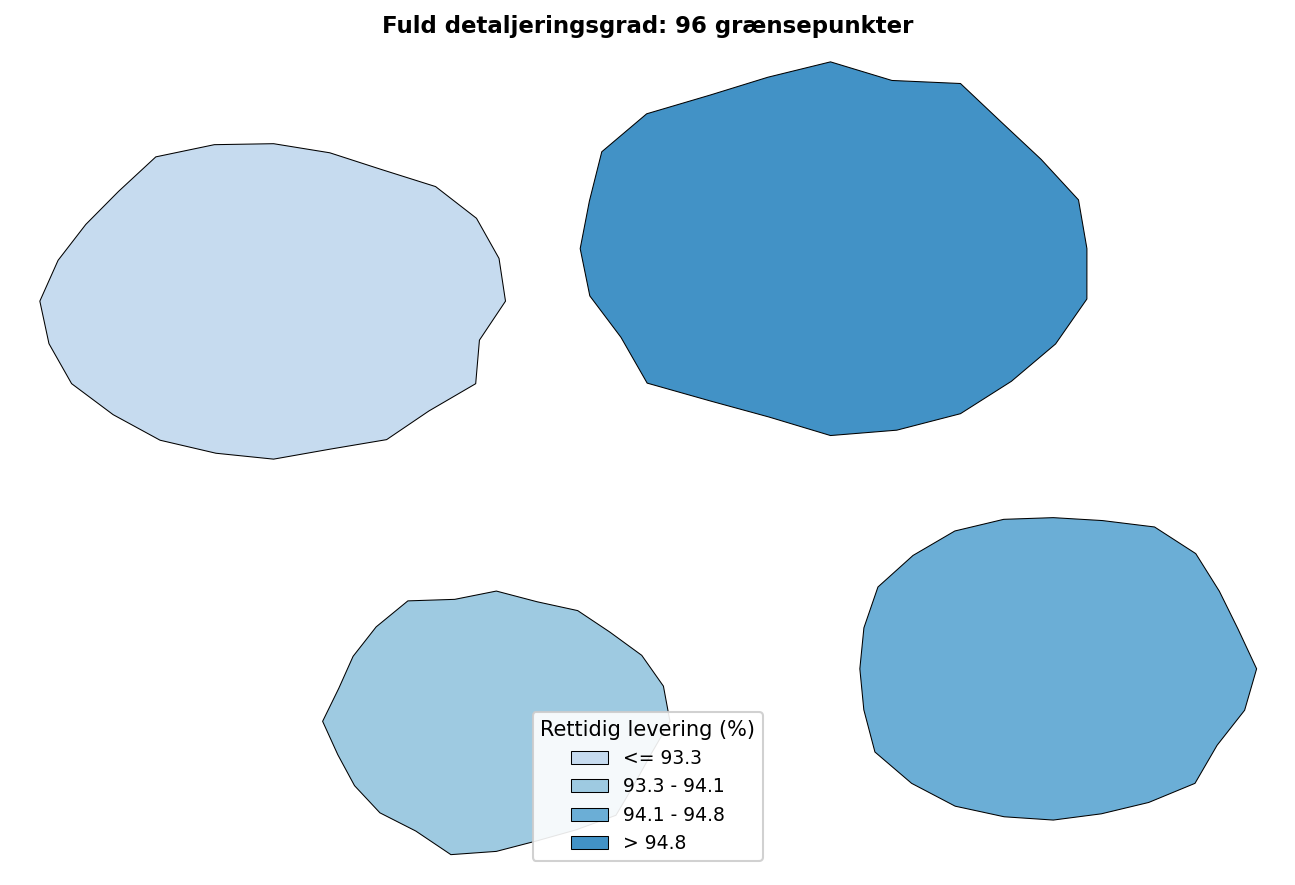

In [5]:
TITEL 'Fuld detaljeringsgrad: 96 grænsepunkter';
PROCEDURE GMAP map=reducedmap data=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
    MÆRKAT ontime_rate="Rettidig levering (%)";
KØR;

                                 Reduceret detaljeringsgrad: 54 punkter (DENSITY <= 2)                                  




NOTE: Option TITLE changed to Reduceret detaljeringsgrad: 54 punkter (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Rettidig levering (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.45 seconds
  cpu   0.45 seconds


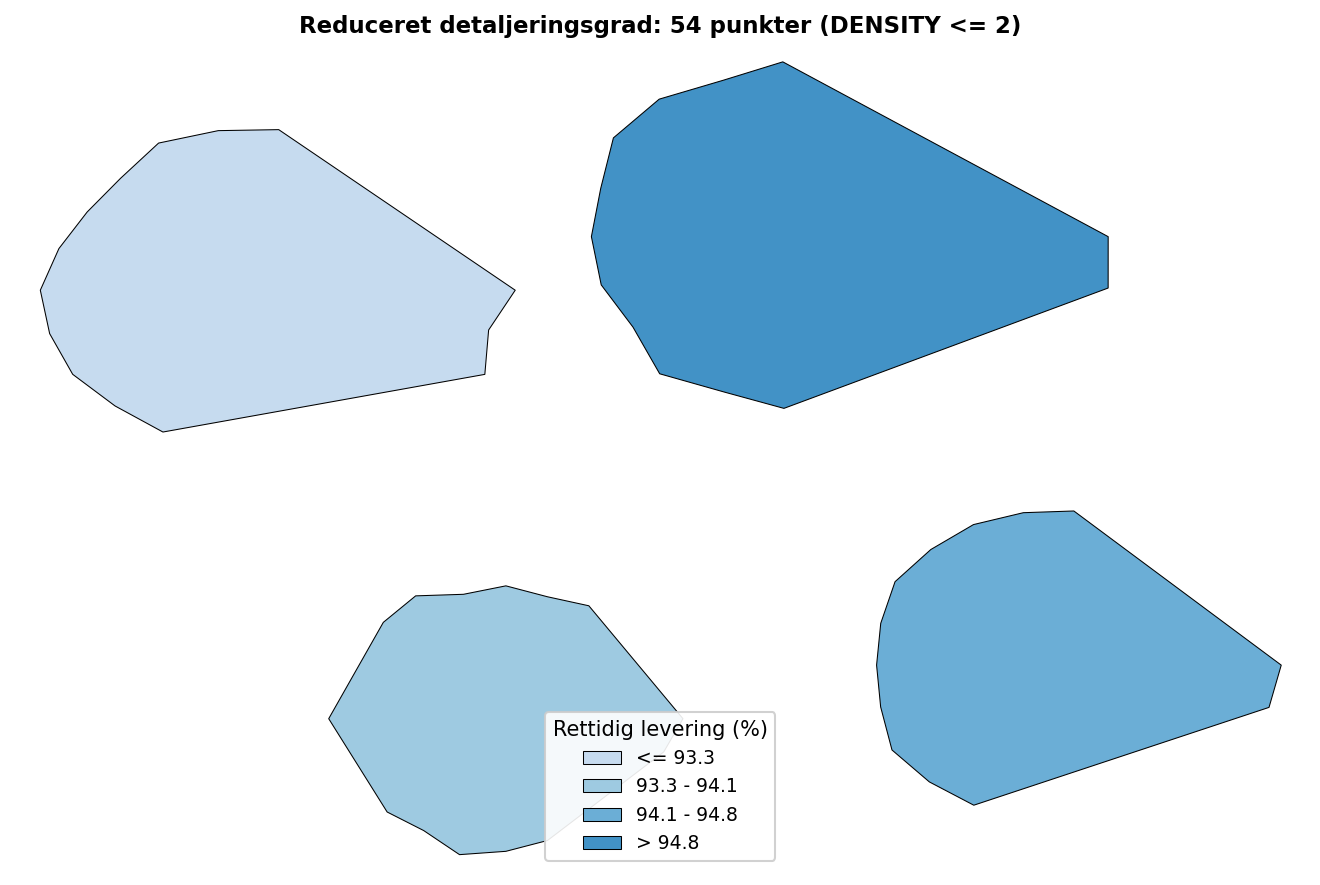

In [6]:
TITEL 'Reduceret detaljeringsgrad: 54 punkter (DENSITY <= 2)';
PROCEDURE GMAP map=coarsemap data=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
    MÆRKAT ontime_rate="Rettidig levering (%)";
KØR;

## Fortolkning af resultaterne

PROC GREDUCE omdannede hver 24-punkts zonekontur til et gradueret sæt grænsepunkter (niveau 0, 2 og 3 i denne kørsel). Ved at vælge niveauet `DENSITY <= 2` blev kortet reduceret fra 96 til 54 punkter — en reduktion på 44 % i de punkter, renderen skal tegne — men de sammenlignede choropleth-kort bekræfter, at de fire zoner forbliver tydeligt genkendelige: konturerne på det reducerede kort er synligt mere kantede, men hvert territorium bevarer sin position, størrelse og farvebånd, så en operatør læser det samme scorecard uanset hvad.

Det scorecard rangerer zonerne efter andel af rettidig levering: zone 2 fører med 95,6 % (mørkeste bånd), zone 3 og 4 ligger midt i feltet omkring 93-95 %, og zone 1 er sidst med 92,6 % (lyseste bånd) — det territorium, en planlægger først ville undersøge for rute- eller depotkapacitetsproblemer.

Fordi reduktionen ikke er destruktiv — punkterne med fuld detalje findes stadig i `reducedmap` — understøtter det samme datasæt både den hurtige dashboardvisning (`DENSITY <= 2`) og en visning med høj opløsning til print eller audit (`DENSITY <= 3`, eller hele sættet) ved blot at ændre en enkelt `WHERE`-tærskel, uden behov for at genimportere eller genreducere geometrien.